In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initialise vars

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/new'

In [5]:
news_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_news_comments.csv'
nonnews_merged_filepath = '/Users/brahmaninutakki/saarland/insta_comments/saved_data/merged_data_nonnews_comments.csv'

In [6]:
news_df = pd.read_csv(news_merged_filepath)
nonnews_df = pd.read_csv(nonnews_merged_filepath) 

In [7]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [8]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in nonnews_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

nonnews_df['caption_text'] = nonnews_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [9]:
news_df.shape, nonnews_df.shape

((1279, 14), (1367, 14))

In [10]:
news_df.drop(columns=['caption'], inplace=True)
nonnews_df.drop(columns=['caption'], inplace=True)

In [11]:
nonnews_df[['account', 'urlid', 'comment_num']].duplicated().sum()

np.int64(330)

In [12]:
keys = ['account', 'urlid', 'comment_num']

news_df = (
    news_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

news_df[keys].duplicated().sum()

np.int64(0)

In [13]:
keys = ['account', 'urlid', 'comment_num']

nonnews_df = (
    nonnews_df
    .groupby(keys, sort=False, as_index=False)
    .agg(lambda s: s.dropna().iloc[0] if s.notna().any() else np.nan)
)

nonnews_df[keys].duplicated().sum()

np.int64(0)

In [14]:
news_df.shape, nonnews_df.shape

((980, 13), (1037, 13))

### plotting

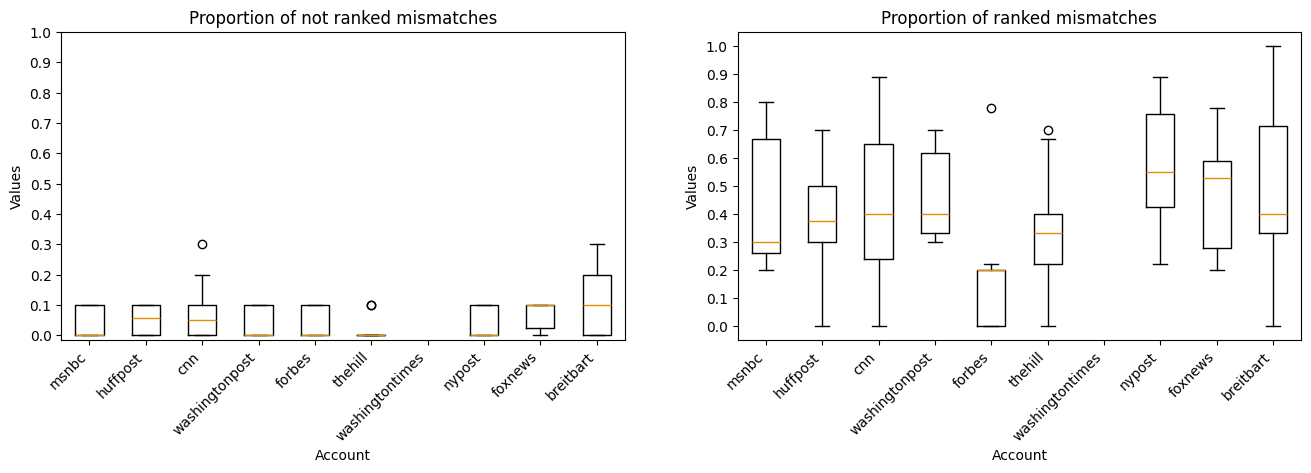

In [15]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'male_dem_ny_1'
crawl2 = 'female_rep_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [16]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

news_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
news_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

news_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

news_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     news_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     news_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

In [17]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

nonnews_mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
nonnews_mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

nonnews_mismatch_no_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_no_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_rank_df.rename(columns={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)

nonnews_mismatch_rank_df.rename(index={
    'male_dem_ny_1': 'Male_Dem_NY',
    'male_dem_texas_1': 'Male_Dem_Texas',
    'male_rep_ny_1': 'Male_Rep_NY',
    'male_rep_texas_1': 'Male_Rep_Texas',
    'female_dem_ny_1': 'Female_Dem_NY',
    'female_dem_texas_1': 'Female_Dem_Texas',
    'female_rep_ny_1': 'Female_Rep_NY',
    'female_rep_texas_1': 'Female_Rep_Texas',
}, inplace=True)


# fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# hm0 = sns.heatmap(
#     nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[0], cbar=False
# )
# axes[0].set_title(f"Average mismatch proportion for {flag} accounts across all pairs of crawls")

# hm1 = sns.heatmap(
#     nonnews_mismatch_rank_df, annot=True, fmt=".2f",
#     cmap="Reds", vmin=0, vmax=1,
#     ax=axes[1], cbar=False
# )
# axes[1].set_title(f"Rank mismatch: {flag}")

# cbar = fig.colorbar(
#     hm0.collections[0],
#     ax=axes,
#     orientation="vertical",
#     location="left", 
#     pad=0.02,
#     fraction=0.06,
#     aspect=40
# )
# cbar.ax.xaxis.set_ticks_position("top")
# cbar.ax.xaxis.set_label_position("top")

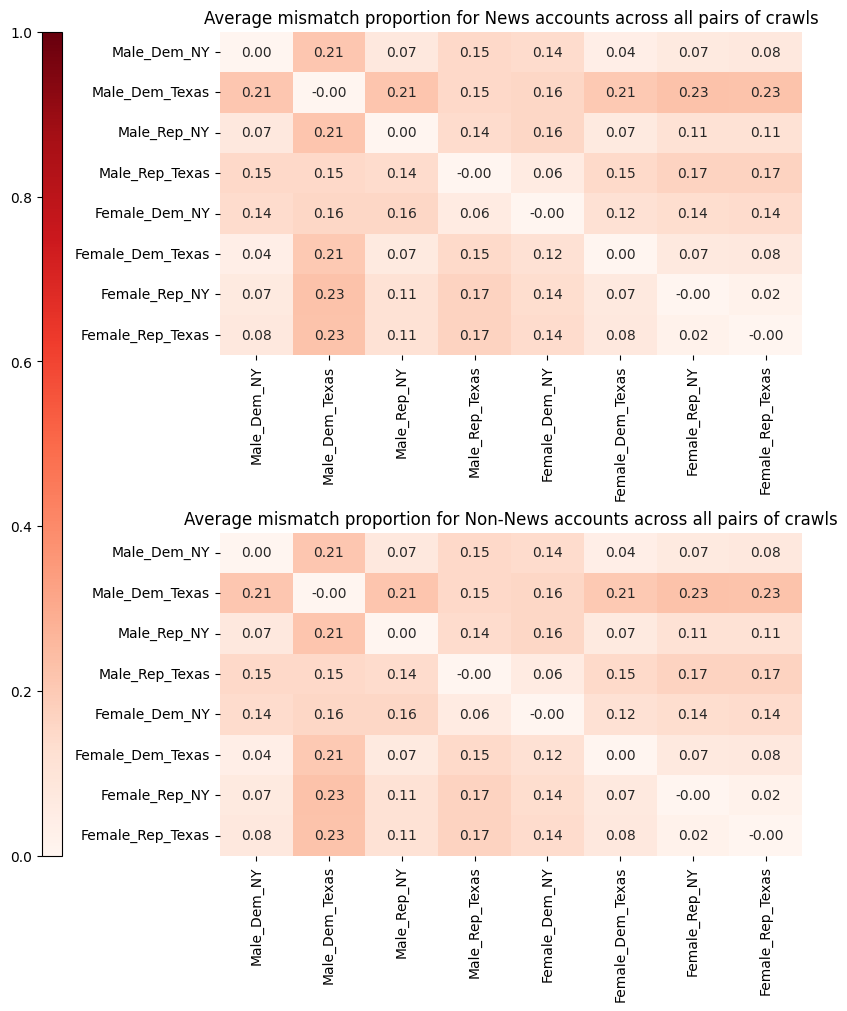

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

hm0 = sns.heatmap(
    news_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"Average mismatch proportion for News accounts across all pairs of crawls")

hm1 = sns.heatmap(
    nonnews_mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Average mismatch proportion for Non-News accounts across all pairs of crawls")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/heatmaps_no_rank.png',
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.15)

### post level reg 

In [20]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls) 

In [21]:
reg_news_df.shape, reg_nonnews_df.shape

((4648, 9), (4312, 9))

In [22]:
reg_news_df.drop_duplicates(inplace=True)
reg_nonnews_df.drop_duplicates(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2114, 9), (2087, 9))

In [23]:
reg_news_df.dropna(inplace=True)
reg_nonnews_df.dropna(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2114, 9), (2087, 9))

In [24]:
display(reg_news_df[reg_news_df['fcount_no_rank'] == -1].shape), display(reg_nonnews_df[reg_nonnews_df['fcount_no_rank'] == -1].shape)
reg_news_df = reg_news_df[reg_news_df['fcount_no_rank'] != -1]
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['fcount_no_rank'] != -1]

reg_news_df.shape, reg_nonnews_df.shape

(45, 9)

(39, 9)

((2069, 9), (2048, 9))

In [25]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2048, 12)

In [26]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2069, 15)

In [27]:
with open('/Users/brahmaninutakki/saarland/insta_comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [28]:
with open('/Users/brahmaninutakki/saarland/insta_comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX7mPtkhbo',
       'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z', 'DRK7-xAEaGg',
       'DRNAF39ESYr', 'DRNI1TVEZ90', 'DRNOKZMkZv9', 'DRVZKhOkeKw',
       'DRV4-1ck1EG', 'DRXO1Q9Co1Y', 'DRX71AeCgTh', 'DRYGzcyEsGL'],
      dtype=object)

In [29]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')

reg_news_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,1392.000000,677.000000
mean,849.701149,1681.441654
std,2137.699421,2728.958771
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [30]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_mising"])
reg_news_df[['comments_count', 'comments_mising']].describe()
reg_news_df.drop(columns=['comments_mising'], inplace=True)

In [31]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']

In [32]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta_comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2069, 21)

In [33]:
reg_news_df['type'] = 'News'
reg_nonnews_df['main_topic'] = 'Non-Political'
reg_nonnews_df['type'] = 'Non-News'

In [34]:
concat_df = pd.concat([reg_nonnews_df, reg_news_df], ignore_index=True)
concat_df.shape

(4114, 22)

In [35]:
def preprocess_reg(df):
    df['fcount_no_rank'] = df['fcount_no_rank'].astype(int)
    df['ftrials_no_rank'] = df['ftrials_no_rank'].astype(int)
    df['fcount_rank'] = df['fcount_rank'].astype(int)
    df['ftrials_rank'] = df['ftrials_rank'].astype(int)

    (df[df['fcount_no_rank'] > df['ftrials_no_rank']]).shape, (df[df['fcount_rank'] > df['ftrials_rank']]).shape

    df['gender_diff'] = df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
    df['location_diff'] = df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
    df['ideology_diff'] = df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

    for col in ["posts", "followers", "following", "comments_count"]:
        new = col + "_logz"
        x = np.log1p(df[col].astype(float))
        df[new] = (x - x.mean()) / x.std(ddof=0)


    df["gender"] = pd.Categorical(
        df["gender"],
        categories=["male_male", "female_male", "female_female"],
        ordered=True
    )

    df["ideology"] = pd.Categorical(
        df["ideology"],
        categories=["rep_rep", "dem_rep", "dem_dem"],
        ordered=True
    )

    df["location"] = pd.Categorical(
        df["location"],
        categories=["texas_texas", "ny_texas", "ny_ny"],
        ordered=True
    )

    df['type'] = pd.Categorical(
        df['type'],
        categories=['Non-News', 'News'],
        ordered=True
    )


    df['main_topic'] = pd.Categorical(
        df['main_topic'],
        categories=['Political', 'Non-Political'],
        ordered=True
    )

    df["gender_diff"] = pd.Categorical(
        df["gender_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["ideology_diff"] = pd.Categorical(
        df["ideology_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    df["location_diff"] = pd.Categorical(
        df["location_diff"],
        categories=["No", "Yes"],
        ordered=True
    )

    return df

In [36]:
concat_df = preprocess_reg(concat_df)
reg_news_df = preprocess_reg(reg_news_df)
reg_nonnews_df = preprocess_reg(reg_nonnews_df)

In [37]:
news_df['account'].value_counts()

account
cnn               130
foxnews           119
nypost            112
huffpost          110
breitbart         108
msnbc             105
thehill           105
forbes             99
washingtonpost     92
Name: count, dtype: int64

In [38]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + C(type) + C(main_topic) + followers_logz + comments_count_logz + followers_logz + following_logz + posts_logz " 
get_vif(formula, concat_df)

,feature,VIF
8,following_logz,1.040989
1,gender_diff[T.Yes],1.081578
3,ideology_diff[T.Yes],1.083115
2,location_diff[T.Yes],1.091950
9,posts_logz,1.159960
6,followers_logz,1.276795
7,comments_count_logz,1.365146
4,C(type)[T.News],1.506742
5,C(main_topic)[T.Non-Political],1.771937
0,Intercept,16.689596


#### combined

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, main_topic, type, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 696 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.897,0.284,-2.398,-1.348,0.009,0.005,1021.0,1946.0,1.00
Location Diff [Yes][Yes],-0.194,0.035,-0.258,-0.127,0.000,0.000,12156.0,6370.0,1.00
Gender Diff [Yes][Yes],0.147,0.036,0.076,0.210,0.000,0.000,13923.0,5709.0,1.00
Leaning Diff [Yes][Yes],0.106,0.036,0.038,0.171,0.000,0.000,13231.0,6589.0,1.00
Comments (log z),0.635,0.102,0.441,0.827,0.003,0.002,932.0,1830.0,1.00
Account Type[News],-1.281,0.215,-1.684,-0.874,0.007,0.003,1080.0,2112.0,1.00
Followers (log z),-0.249,0.100,-0.432,-0.062,0.004,0.002,805.0,1292.0,1.01
Post Type [Non-Political][Non-Political],-0.175,0.266,-0.673,0.324,0.008,0.005,983.0,1630.0,1.00


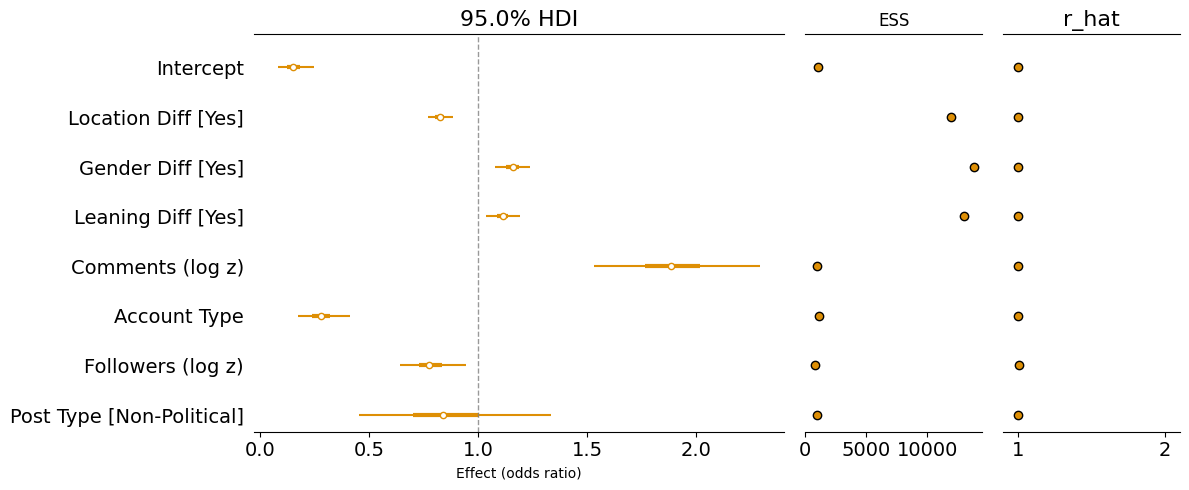

In [40]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + main_topic + type + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
    prob=0.95
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'comments_count_logz', 'type', 'followers_logz', 'main_topic']

df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1',
    combined=True,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
axes[1].set_title("ESS")
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/forestplot_combined.png', dpi=300)

Default computed for unspecified variable: comments_count_logz, followers_logz, gender_diff, ideology_diff, main_topic, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, ideology_diff, location_diff, main_topic, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender_diff, location_diff, main_topic, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender_diff, ideology_diff, location_diff, main_topic, urlid
Default computed for conditional variable: followers_logz
Default computed for unspecified variable: comments_count_logz, gender_diff, ideology_diff, location_diff, main_topic, type, urlid
Default computed for conditional variable: comments_count_logz
Default computed for unspecified variable: followers_logz, gender_diff, ideology_diff, location_diff, main_topic, type, urlid


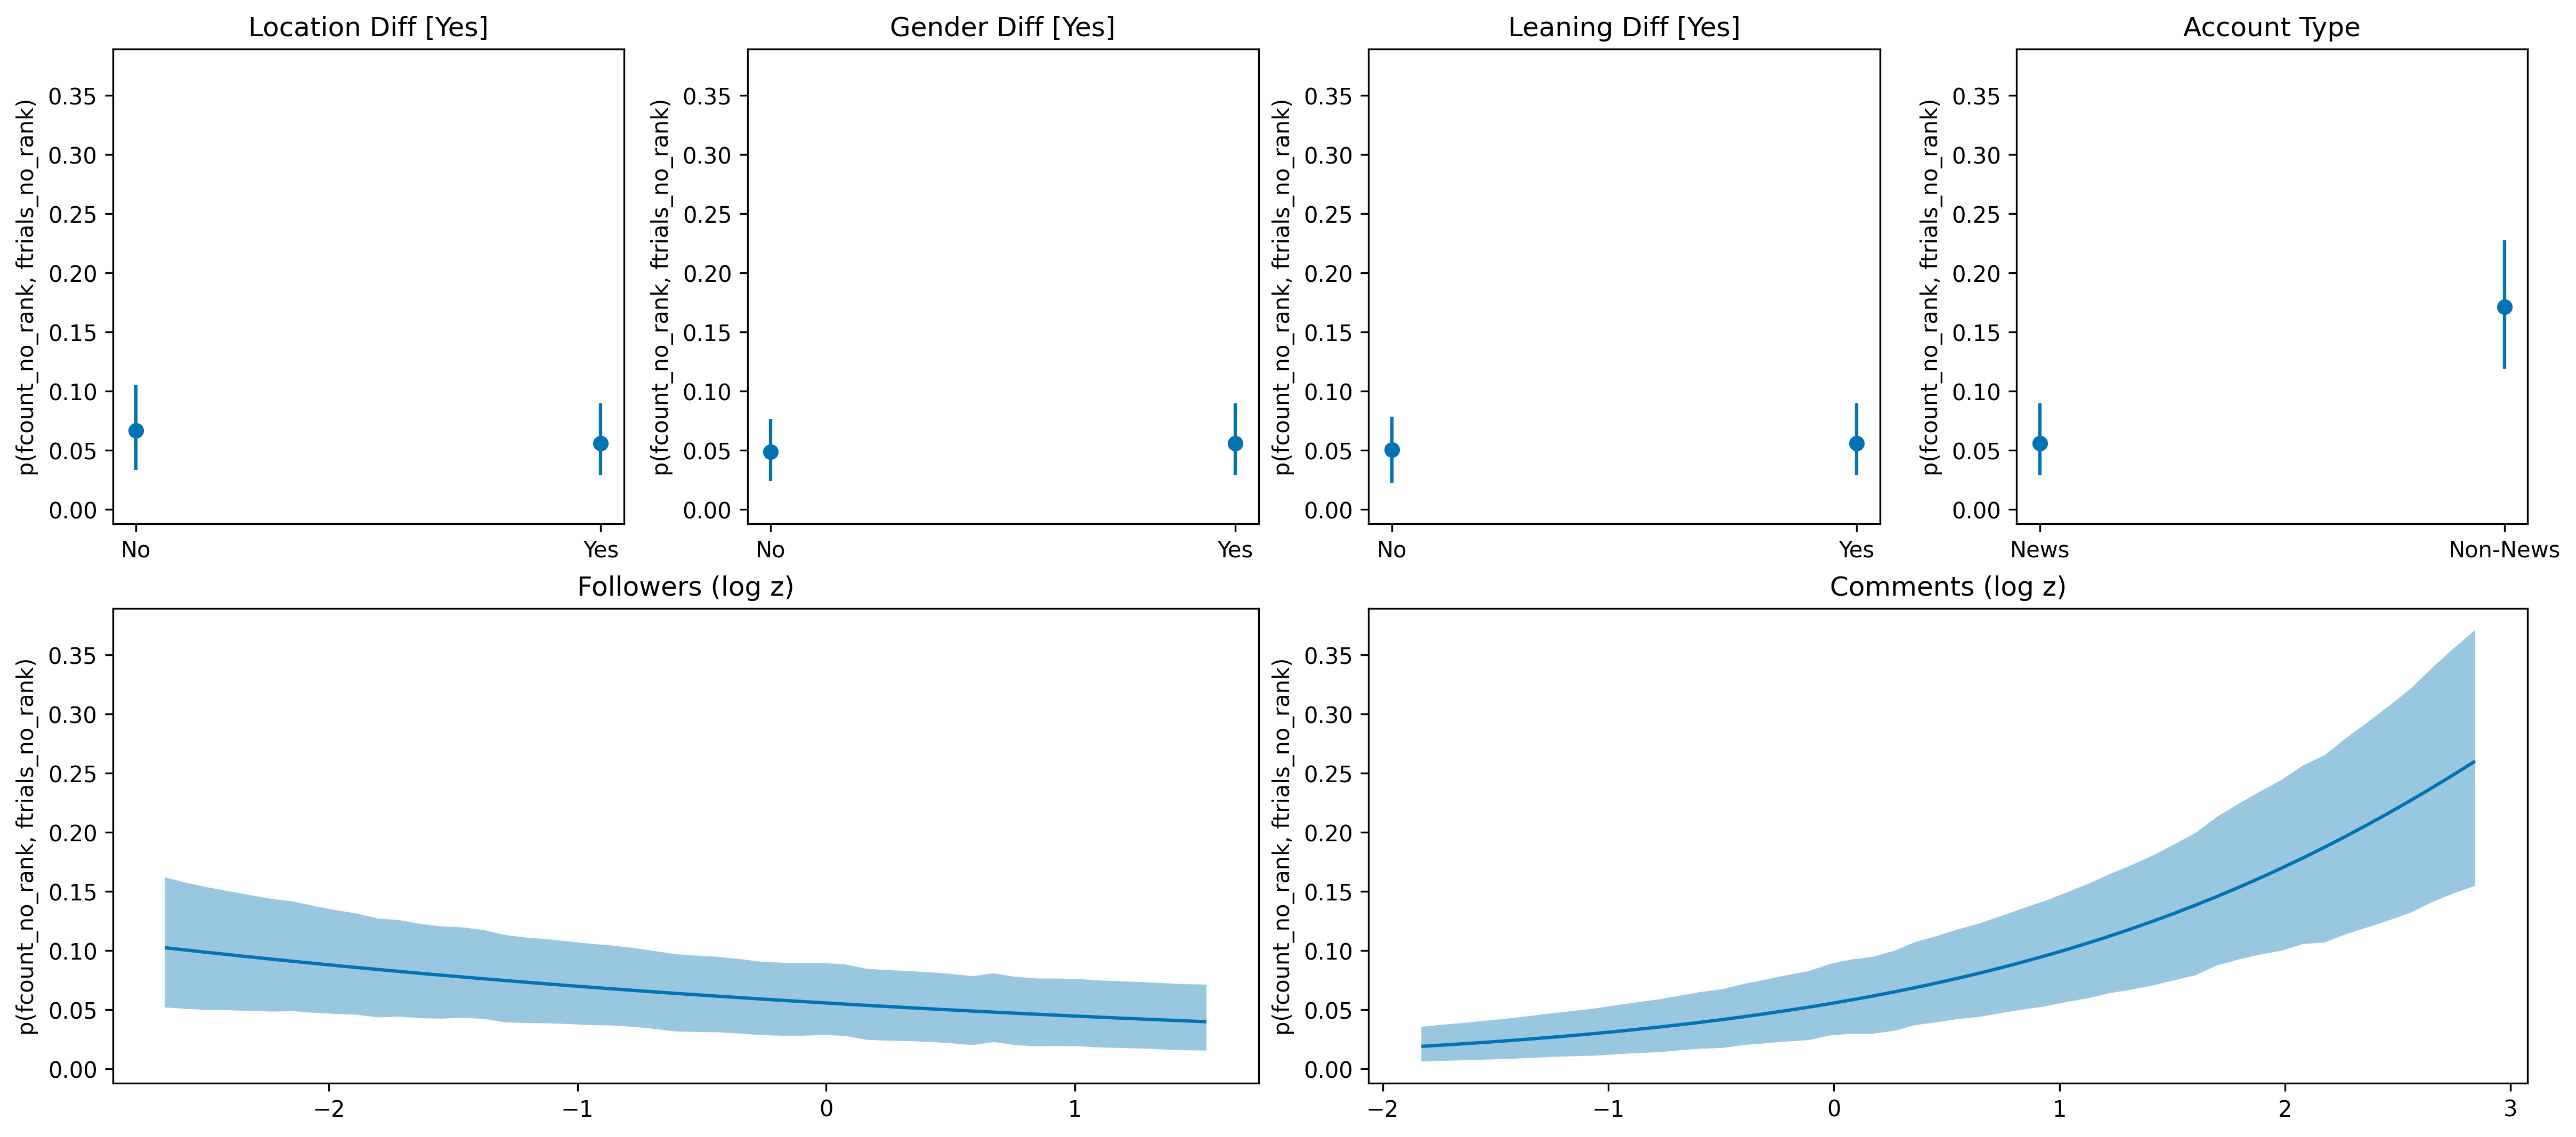

In [41]:
first_row = ["location_diff", "gender_diff", "ideology_diff", "type"]
second_row = ["followers_logz", "comments_count_logz"]
conditionals = first_row + second_row

data = model.data 

fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))

    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass

    # BROWN = "#fa7700"
    # for ln in ax.lines:
    #     ln.set_color(BROWN)

    # for coll in ax.collections:  # often includes the interval band
    #     try:
    #         coll.set_facecolor(BROWN)
    #         coll.set_edgecolor(BROWN)
    #         coll.set_alpha(0.2)
    #     except Exception:
    #         pass

# right_edge_axes = [axes[3], axes[5]]
# for ax in right_edge_axes:
#     ax.yaxis.set_ticks_position("both")
#     ax.tick_params(axis="y", right=True, labelright=True)

# for ax in axes:
#     if ax not in right_edge_axes:
#         ax.tick_params(axis="y", right=True, labelright=False)

# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta_comments/figures/ppp_combined.png', dpi=300)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, main_topic, type, 1|account_sigma, 1|account_offset, main_topic|account_sigma, main_topic|account_offset, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 721 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.704,0.380,-2.431,-0.994,0.008,0.005,2029.0,3035.0,1.0
Location Diff [Yes][Yes],-0.194,0.035,-0.258,-0.128,0.000,0.000,11595.0,6215.0,1.0
Gender Diff [Yes][Yes],0.147,0.035,0.082,0.212,0.000,0.000,11236.0,6026.0,1.0
Leaning Diff [Yes][Yes],0.107,0.036,0.039,0.172,0.000,0.000,11694.0,6192.0,1.0
Account Type [News][News],-1.047,0.318,-1.655,-0.456,0.006,0.004,2817.0,3988.0,1.0
Post Type [Non-Political][Non-Political],-0.586,0.325,-1.190,0.043,0.008,0.005,1855.0,3082.0,1.0


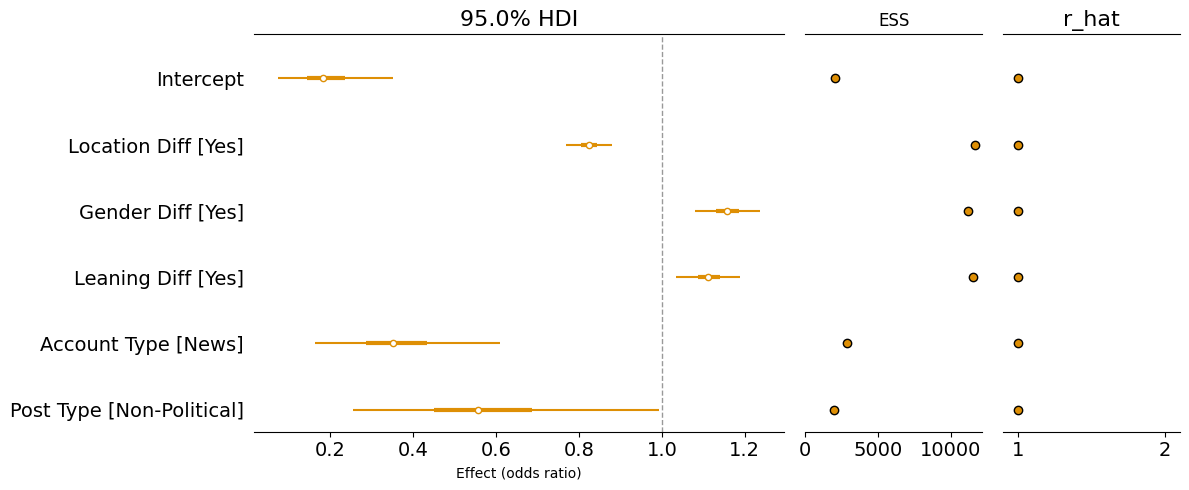

In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + main_topic + type + (1 + main_topic|account) + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
    prob=0.95
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'type', 'main_topic']

df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1',
    combined=True,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
axes[1].set_title("ESS")
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/forestplot_main_topic_combined.png', dpi=300)

Default computed for unspecified variable: account, gender_diff, ideology_diff, main_topic, type, urlid
Default computed for unspecified variable: account, ideology_diff, location_diff, main_topic, type, urlid
Default computed for unspecified variable: account, gender_diff, location_diff, main_topic, type, urlid
Default computed for unspecified variable: account, gender_diff, ideology_diff, location_diff, type, urlid
Default computed for unspecified variable: account, gender_diff, ideology_diff, location_diff, main_topic, urlid


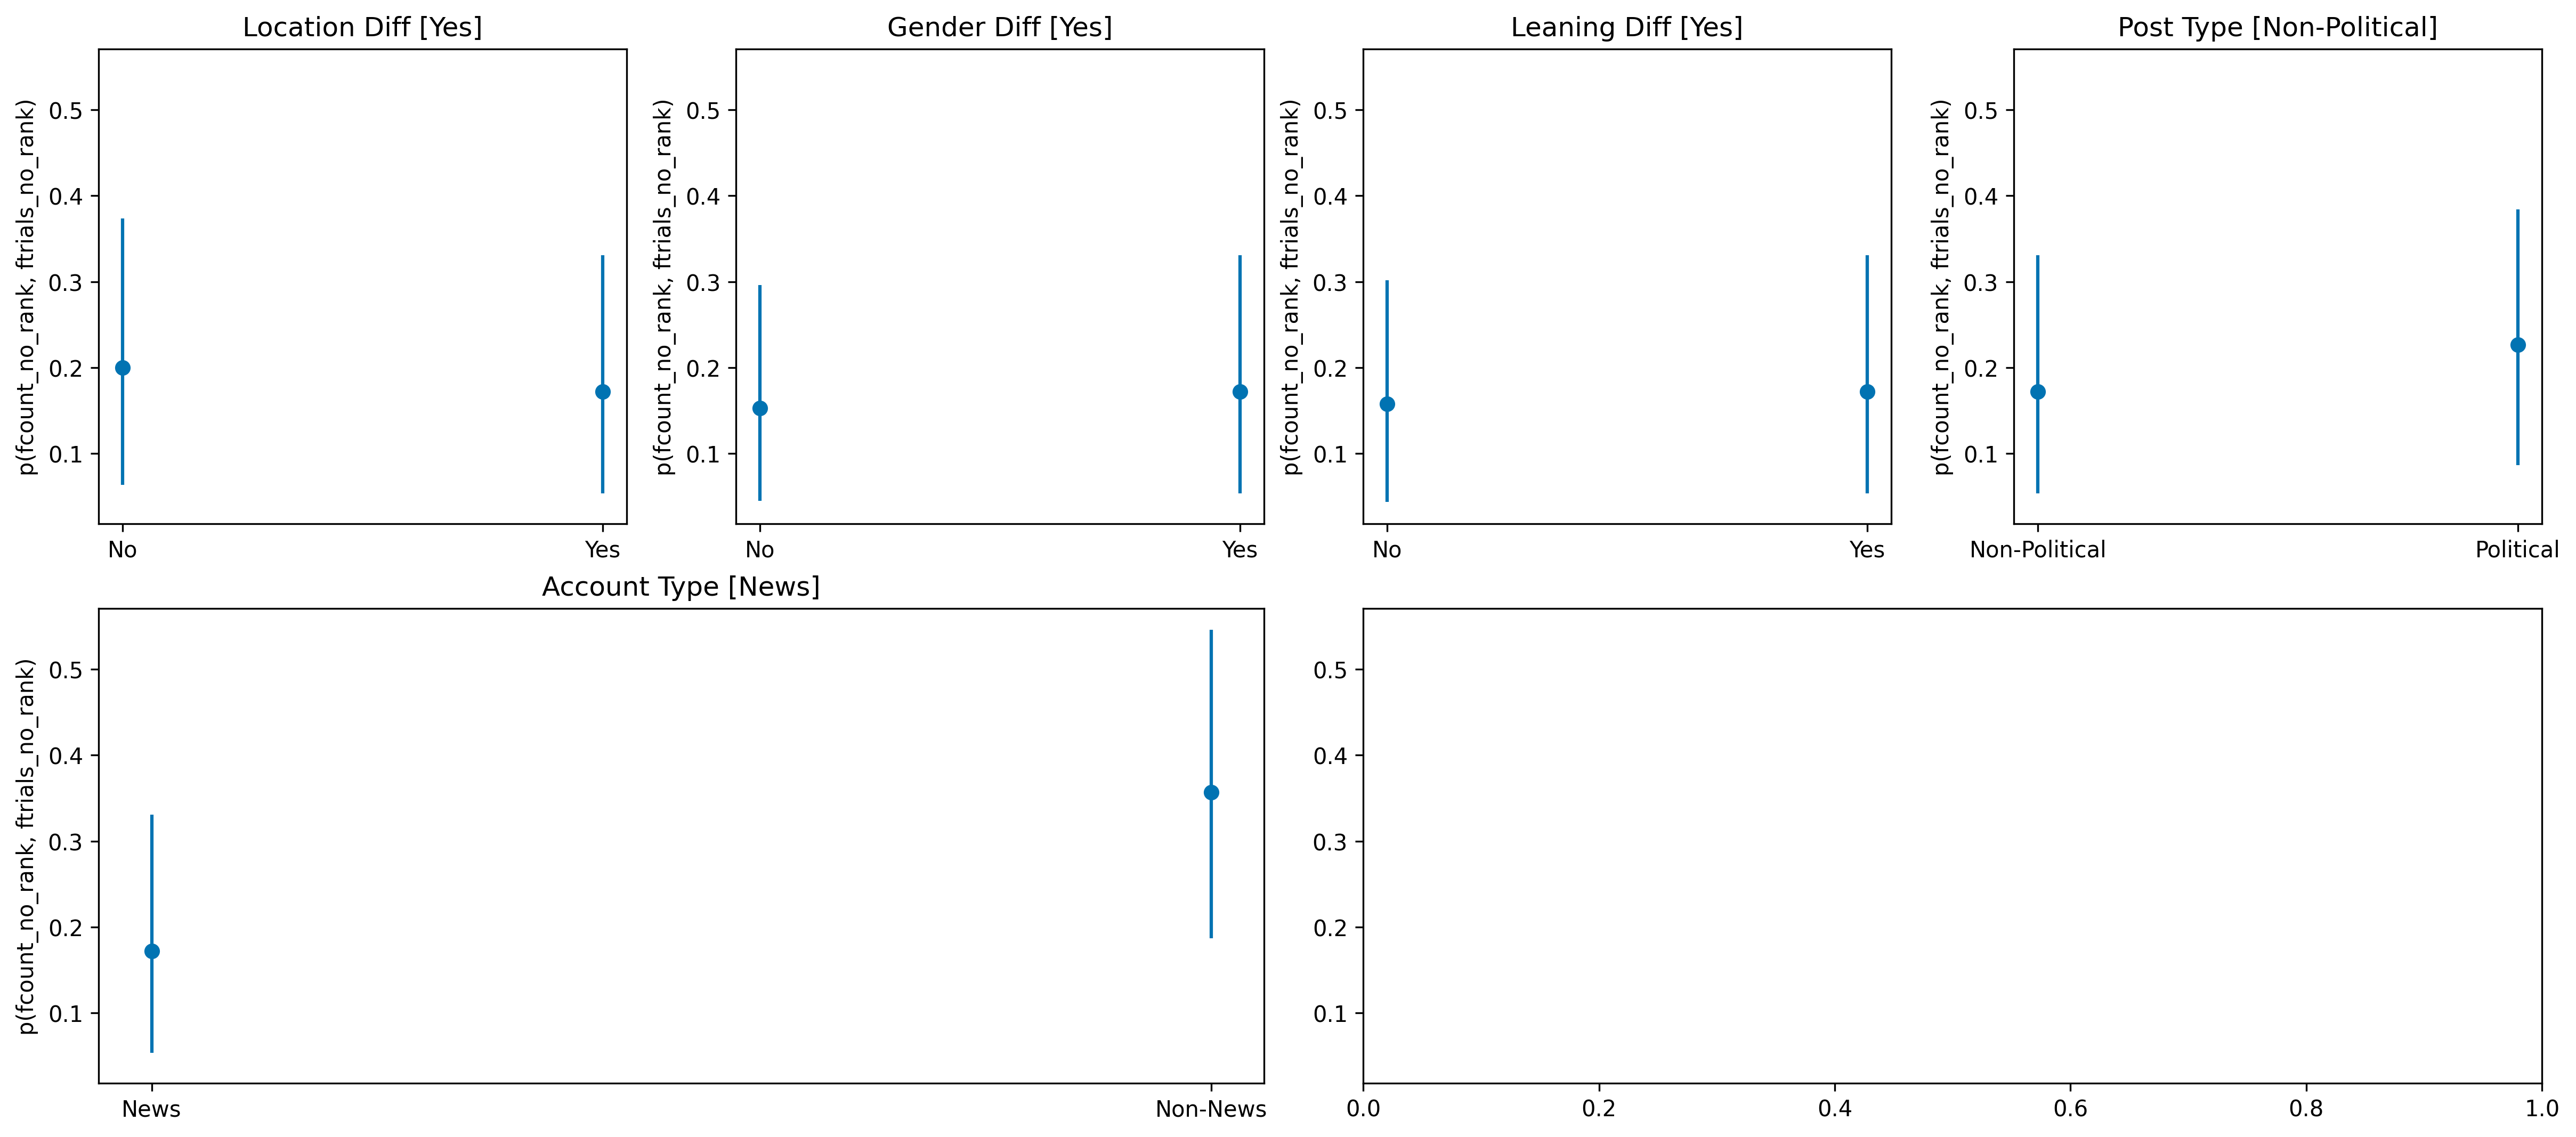

In [39]:
first_row = ["location_diff", "gender_diff", "ideology_diff"]
second_row = ["main_topic", "type"]
conditionals = first_row + second_row

data = model.data 

fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))

    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass

    # BROWN = "#fa7700"
    # for ln in ax.lines:
    #     ln.set_color(BROWN)

    # for coll in ax.collections:  # often includes the interval band
    #     try:
    #         coll.set_facecolor(BROWN)
    #         coll.set_edgecolor(BROWN)
    #         coll.set_alpha(0.2)
    #     except Exception:
    #         pass

# right_edge_axes = [axes[3], axes[5]]
# for ax in right_edge_axes:
#     ax.yaxis.set_ticks_position("both")
#     ax.tick_params(axis="y", right=True, labelright=True)

# for ax in axes:
#     if ax not in right_edge_axes:
#         ax.tick_params(axis="y", right=True, labelright=False)

# plt.show()
plt.savefig('/Users/brahmaninutakki/saarland/insta-comments/figures/ppp_combined.png', dpi=300)

In [38]:
# # plot followers and main topic

# df = concat_df.copy()
# df["followers"] = pd.to_numeric(df["followers"], errors="coerce")

# for topic, s in df.dropna(subset=["main_topic", "followers"]).groupby("main_topic")["followers"]:
#     plt.figure()
#     plt.hist(s, bins=20)
#     plt.title(f"followers histogram — {topic}")
#     plt.xlabel("followers")
#     plt.ylabel("count")
#     plt.tight_layout()
#     plt.show()


In [ ]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + type + account + main_topic + (1|urlid)",
#     data=concat_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=1,
#     random_seed=42,
#     prob=0.95
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'comments_count_logz', 'main_topic', 'type', 'followers_logz', 'account']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, followers_logz, comments_count_logz, type, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 669 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.613,0.139,-1.875,-1.354,0.005,0.002,862.0,1820.0,1.01
Location[ny_texas],-0.320,0.041,-0.397,-0.242,0.000,0.000,7825.0,5855.0,1.00
Location[ny_ny],-0.268,0.048,-0.359,-0.178,0.001,0.001,8131.0,6225.0,1.00
Gender[female_male],-0.108,0.042,-0.184,-0.028,0.000,0.000,8229.0,5863.0,1.00
Gender[female_female],-0.553,0.054,-0.653,-0.452,0.001,0.001,8709.0,5593.0,1.00
Leaning[dem_rep],0.019,0.042,-0.056,0.099,0.000,0.000,8248.0,6109.0,1.00
Leaning[dem_dem],-0.171,0.051,-0.269,-0.079,0.001,0.001,9252.0,6262.0,1.00
Comments (log z),0.651,0.100,0.463,0.838,0.003,0.002,1016.0,1399.0,1.00
Account Type [News][News],-1.195,0.186,-1.534,-0.835,0.006,0.003,894.0,1717.0,1.01
Followers (log z),-0.268,0.098,-0.454,-0.087,0.004,0.002,647.0,1315.0,1.00


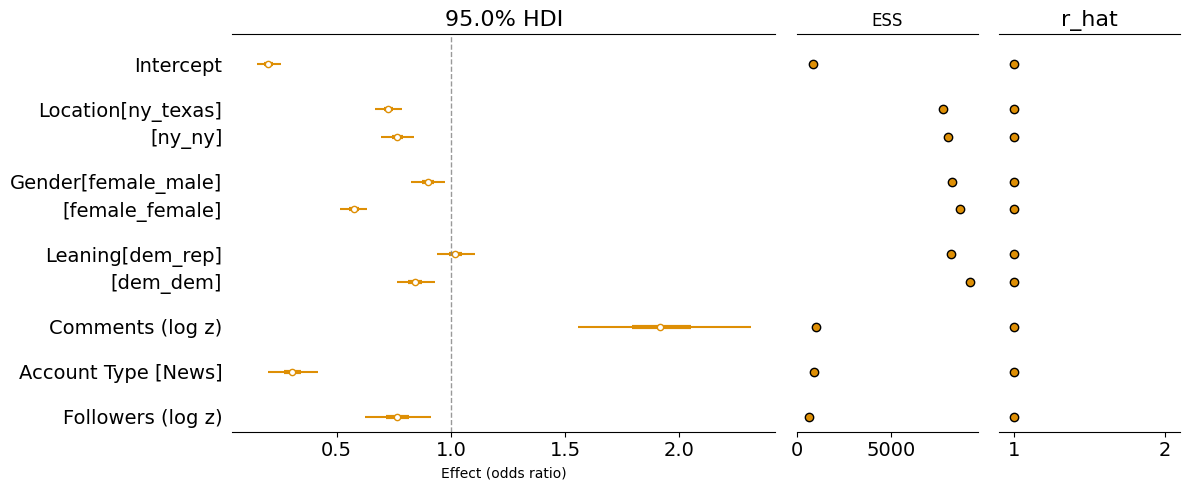

In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + followers_logz + comments_count_logz + type + main_topic + (1|urlid)",
    data=concat_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)

var_names = ['Intercept', 'location', 'gender', 'ideology', 'comments_count_logz', 'type', 'followers_logz', 'main_topic']
df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1'
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)
axes[1].set_title("ESS")

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, ideology, location, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, location, type, urlid
Default computed for unspecified variable: comments_count_logz, followers_logz, gender, ideology, location, urlid
Default computed for conditional variable: followers_logz
Default computed for unspecified variable: comments_count_logz, gender, ideology, location, type, urlid
Default computed for conditional variable: comments_count_logz
Default computed for unspecified variable: followers_logz, gender, ideology, location, type, urlid


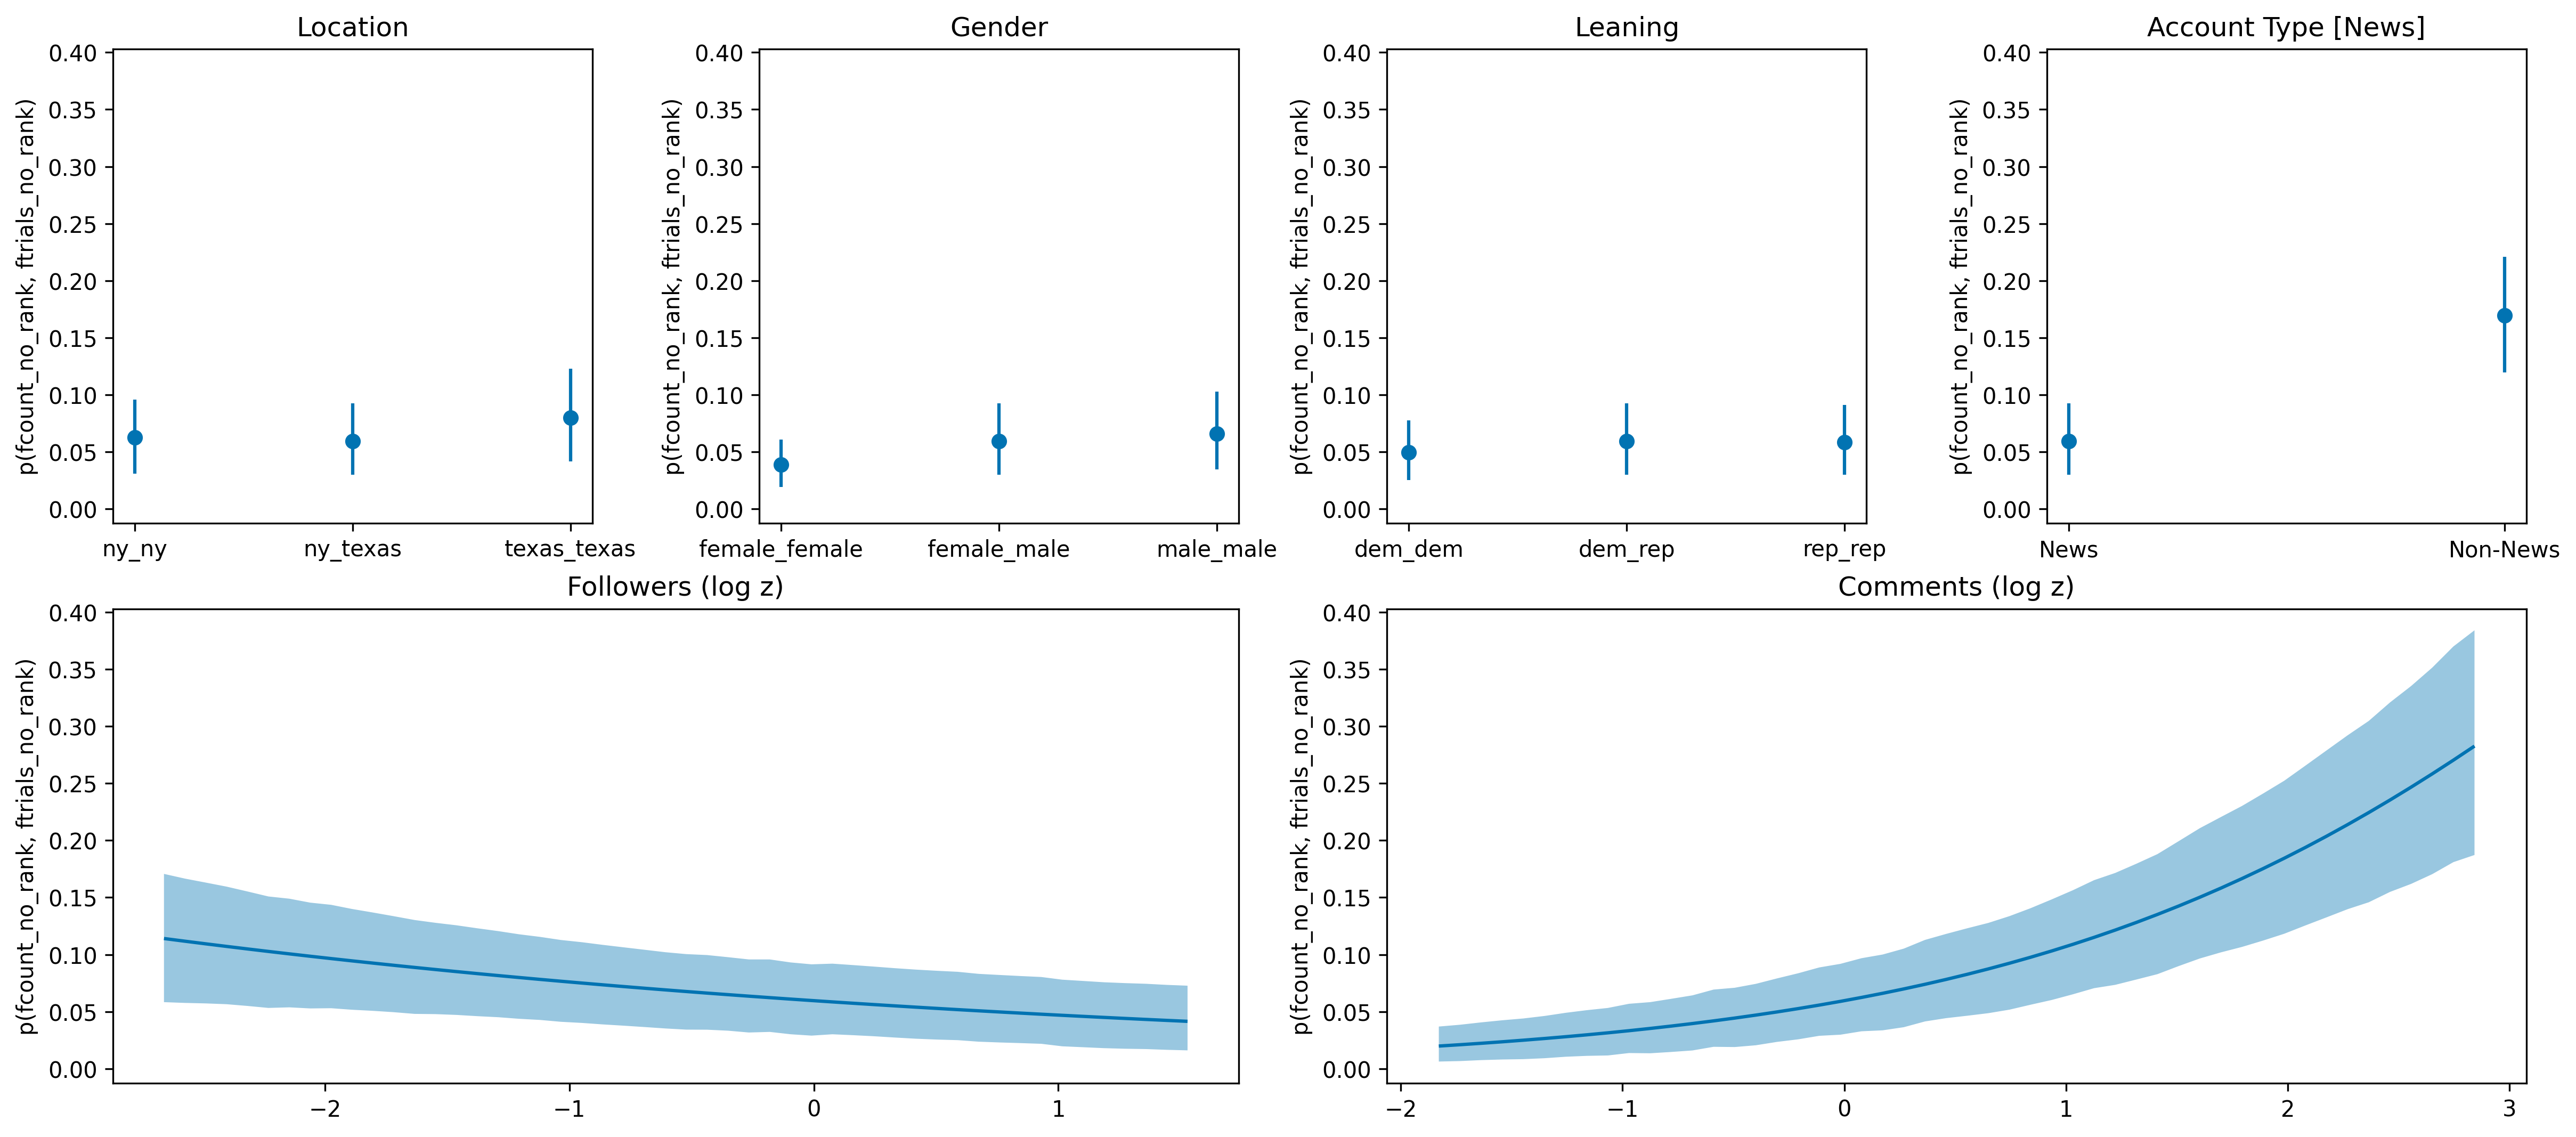

In [36]:
first_row = ["location", "gender", "ideology", "type"]
second_row = ["followers_logz", "comments_count_logz"]
conditionals = first_row + second_row

data = model.data 

fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))

    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass

    # BROWN = "#fa7700"
    # for ln in ax.lines:
    #     ln.set_color(BROWN)

    # for coll in ax.collections:  # often includes the interval band
    #     try:
    #         coll.set_facecolor(BROWN)
    #         coll.set_edgecolor(BROWN)
    #         coll.set_alpha(0.2)
    #     except Exception:
    #         pass

# right_edge_axes = [axes[3], axes[5]]
# for ax in right_edge_axes:
#     ax.yaxis.set_ticks_position("both")
#     ax.tick_params(axis="y", right=True, labelright=True)

# for ax in axes:
#     if ax not in right_edge_axes:
#         ax.tick_params(axis="y", right=True, labelright=False)

plt.show()

#### news only

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 292 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.017,0.245,-3.501,-2.572,0.012,0.007,418.0,698.0,1.02
Location Diff [Yes][Yes],-0.228,0.050,-0.325,-0.137,0.001,0.001,6345.0,5127.0,1.00
Gender Diff [Yes][Yes],0.236,0.051,0.142,0.333,0.001,0.001,6946.0,5502.0,1.00
Leaning Diff [Yes][Yes],0.348,0.052,0.245,0.441,0.001,0.001,6559.0,5820.0,1.00
Post Type [Non-Political][Non-Political],-0.719,0.326,-1.335,-0.097,0.015,0.009,454.0,671.0,1.01


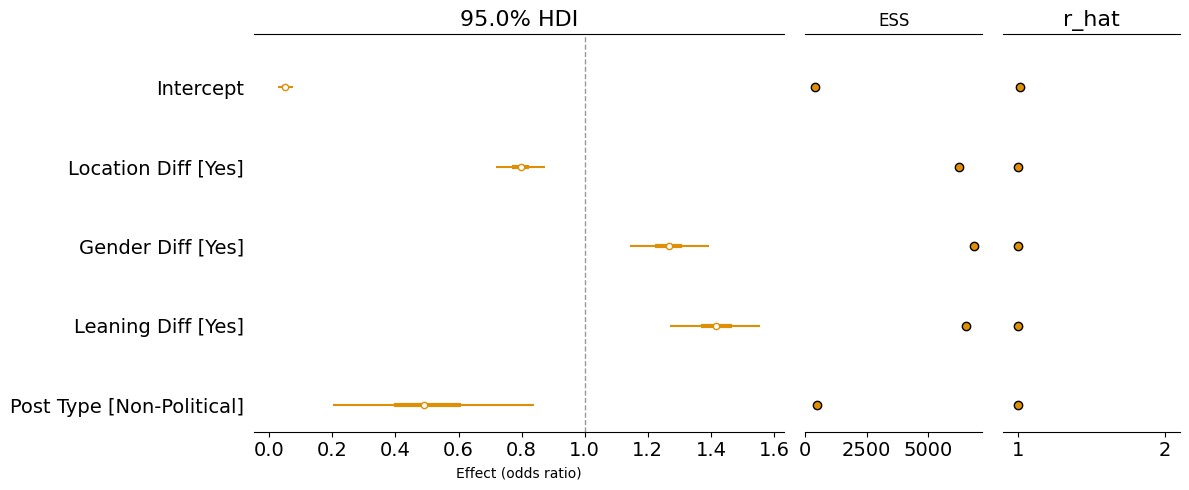

In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + main_topic + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
    prob=0.95,
)

var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
             'main_topic']
df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1'
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)
axes[1].set_title("ESS")

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Default computed for unspecified variable: gender_diff, ideology_diff, main_topic, urlid
Default computed for unspecified variable: ideology_diff, location_diff, main_topic, urlid
Default computed for unspecified variable: gender_diff, location_diff, main_topic, urlid
Default computed for unspecified variable: gender_diff, ideology_diff, location_diff, urlid


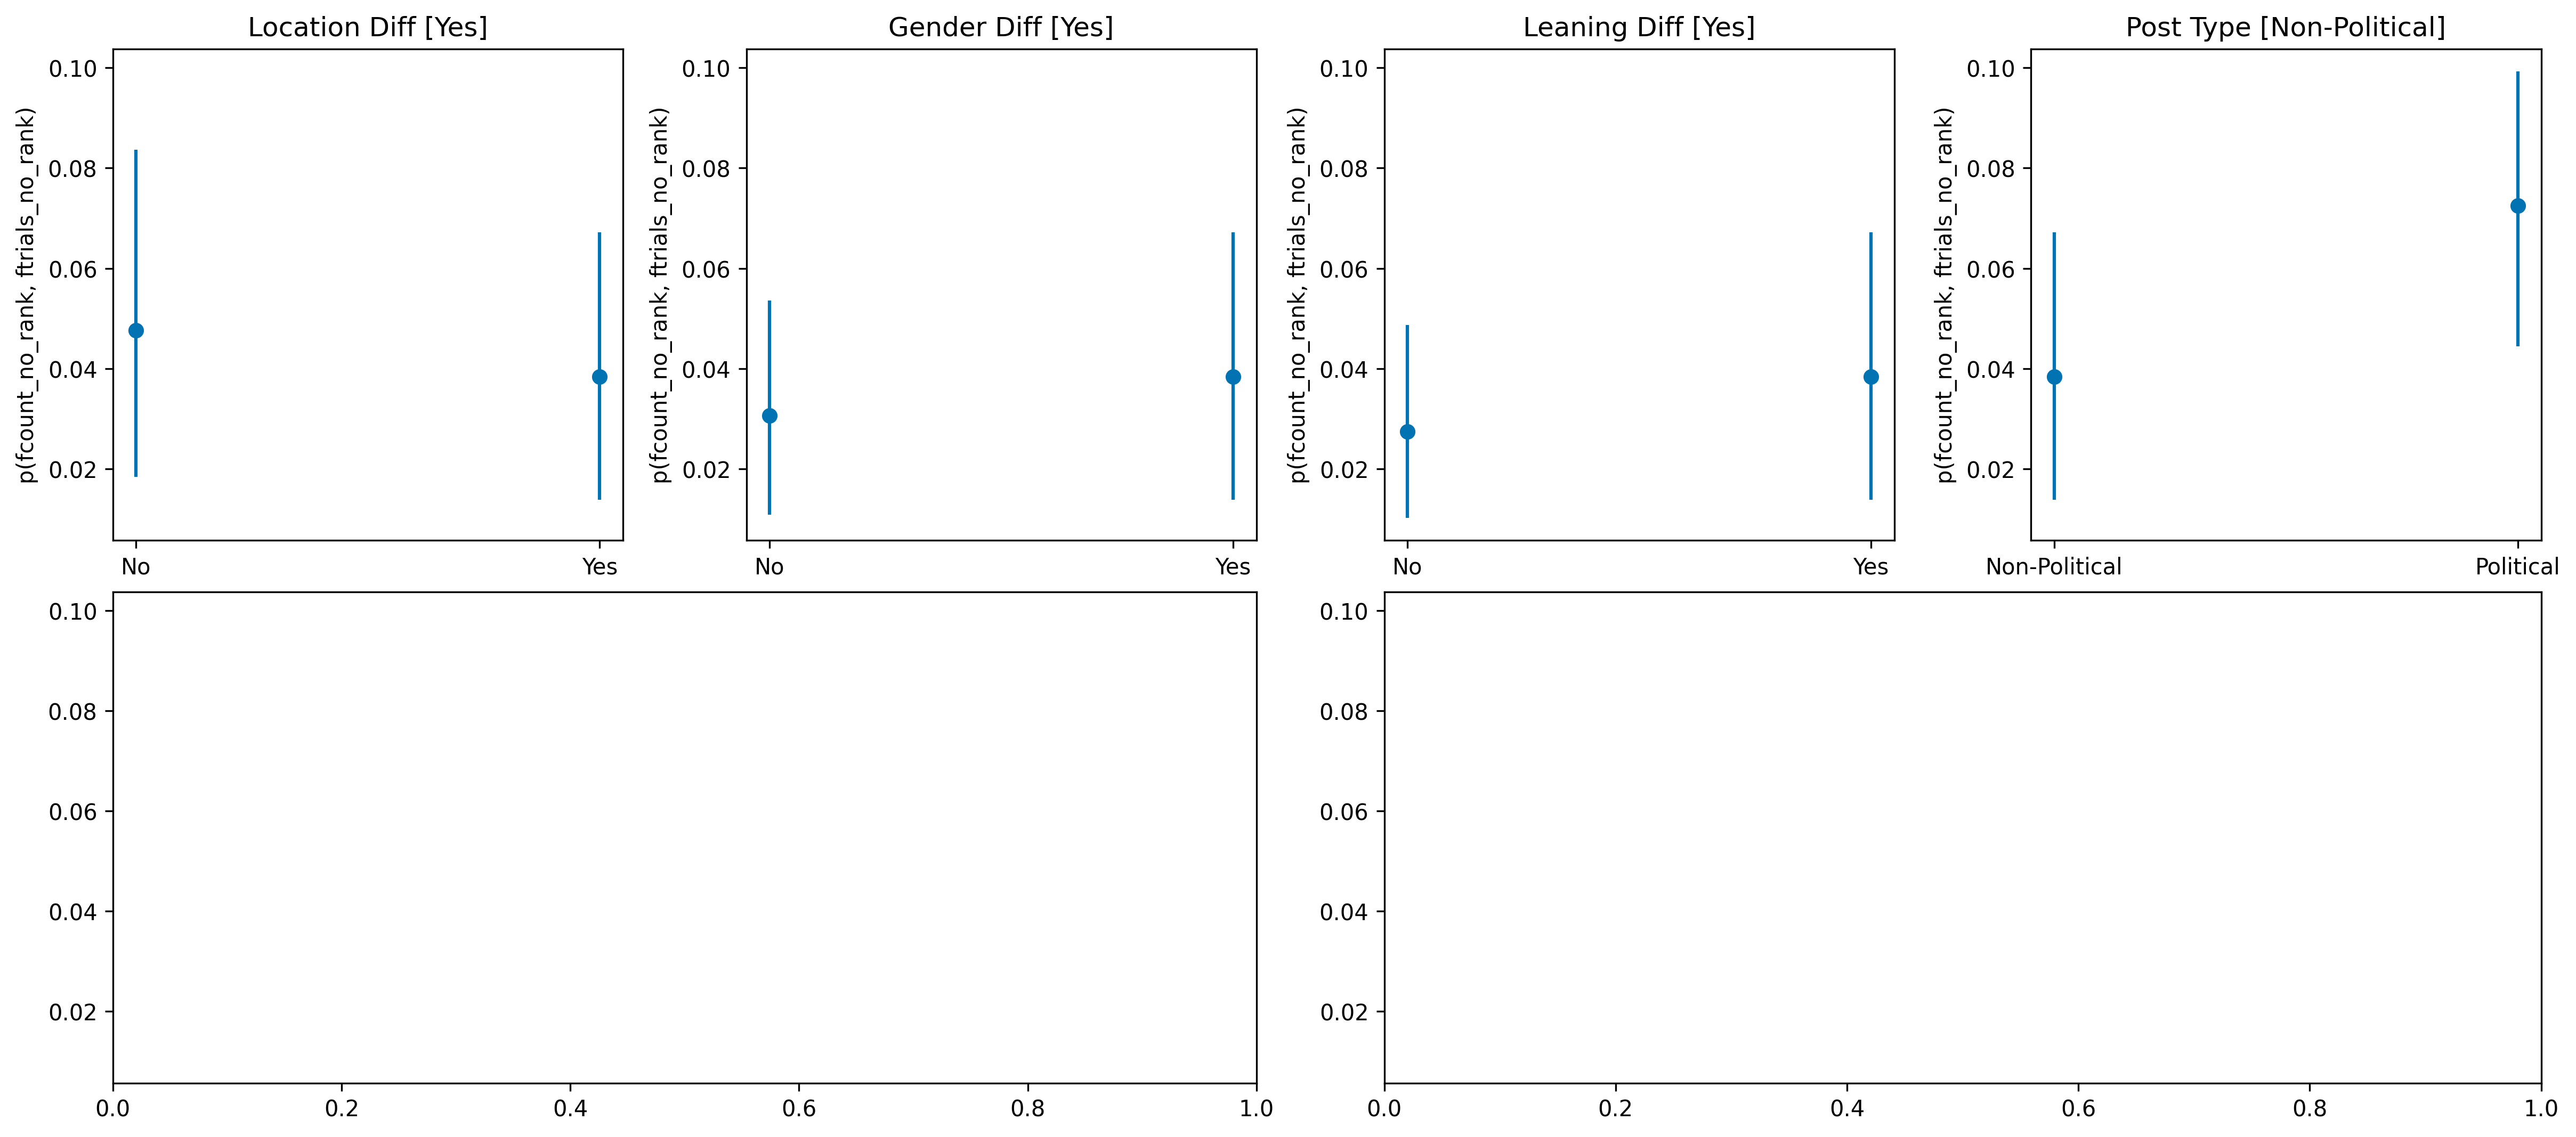

In [36]:
first_row = ["location_diff", "gender_diff"]
second_row = ["ideology_diff", "main_topic"]
conditionals = first_row + second_row

data = model.data 

fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))

    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass

    # BROWN = "#fa7700"
    # for ln in ax.lines:
    #     ln.set_color(BROWN)

    # for coll in ax.collections:  # often includes the interval band
    #     try:
    #         coll.set_facecolor(BROWN)
    #         coll.set_edgecolor(BROWN)
    #         coll.set_alpha(0.2)
    #     except Exception:
    #         pass

# right_edge_axes = [axes[3], axes[5]]
# for ax in right_edge_axes:
#     ax.yaxis.set_ticks_position("both")
#     ax.tick_params(axis="y", right=True, labelright=True)

# for ax in axes:
#     if ax not in right_edge_axes:
#         ax.tick_params(axis="y", right=True, labelright=False)

plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, political_ideology, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 278 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.406,0.532,-4.395,-2.392,0.011,0.008,2313.0,3083.0,1.0
Location (Binary)[Yes],-0.238,0.051,-0.331,-0.141,0.001,0.001,8658.0,5657.0,1.0
Gender (Binary)[Yes],0.235,0.051,0.145,0.335,0.001,0.001,8672.0,5919.0,1.0
Ideology (Binary)[Yes],0.340,0.052,0.240,0.434,0.001,0.001,8865.0,5936.0,1.0
Comments (log z),0.658,0.201,0.289,1.044,0.004,0.003,2455.0,3693.0,1.0
Political vs Non-Political[Non-Political],-0.140,0.457,-1.028,0.695,0.010,0.006,2192.0,3477.0,1.0
political_ideology[Center-Left],0.409,0.696,-0.986,1.634,0.014,0.009,2342.0,3568.0,1.0
political_ideology[Center-Right],-0.310,0.662,-1.552,0.931,0.014,0.009,2287.0,2728.0,1.0
political_ideology[Left],-0.026,0.616,-1.124,1.229,0.013,0.009,2241.0,3050.0,1.0
political_ideology[Right],0.187,0.610,-0.976,1.305,0.013,0.010,2174.0,3225.0,1.0


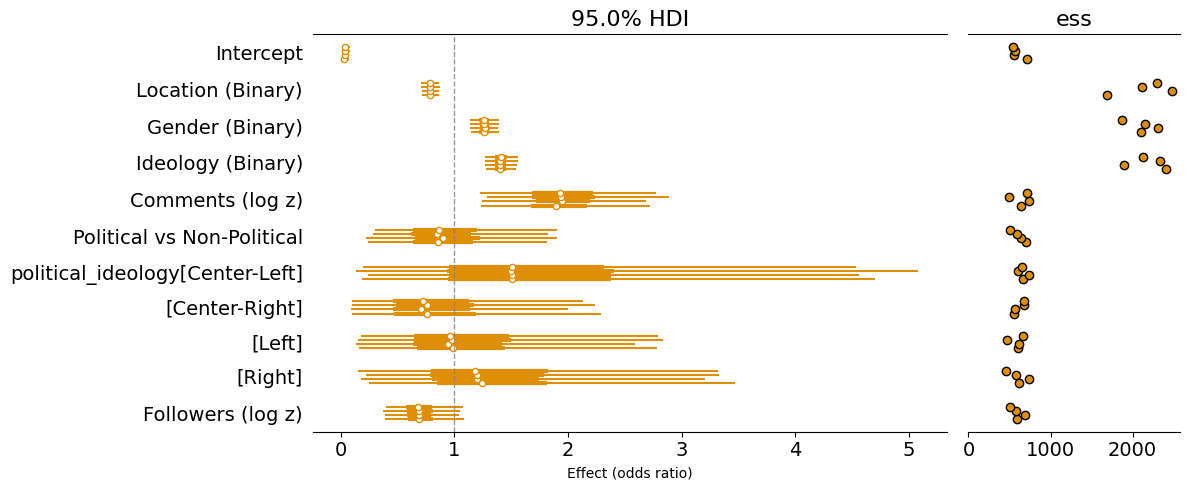

In [34]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + political_ideology + main_topic + (1|urlid)",
#     data=reg_news_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=4,
#     random_seed=42,
#     prob=0.95,
# )

# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
#              'comments_count_logz', 'main_topic', 'political_ideology', 'followers_logz']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, followers_logz, comments_count_logz, political_ideology, main_topic, account, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 6041 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.056,3.308,-9.269,3.079,0.048,0.035,4712.0,5155.0,1.0
Location (Binary)[Yes],-0.238,0.050,-0.332,-0.145,0.000,0.001,15124.0,6315.0,1.0
Gender (Binary)[Yes],0.235,0.050,0.140,0.329,0.000,0.001,15371.0,6021.0,1.0
Ideology (Binary)[Yes],0.340,0.052,0.243,0.437,0.000,0.001,17389.0,6222.0,1.0
Comments (log z),0.906,0.237,0.463,1.356,0.005,0.003,2619.0,3983.0,1.0
Political vs Non-Political[Non-Political],-0.058,0.486,-0.958,0.876,0.010,0.006,2176.0,3777.0,1.0
political_ideology[Center-Left],-0.120,4.672,-9.188,8.345,0.052,0.051,7923.0,5787.0,1.0
political_ideology[Center-Right],-0.224,5.555,-10.500,10.499,0.057,0.064,9341.0,6248.0,1.0
political_ideology[Left],-0.168,4.682,-9.097,8.644,0.061,0.051,5861.0,5672.0,1.0
political_ideology[Right],0.492,3.324,-5.692,6.726,0.049,0.036,4648.0,5385.0,1.0


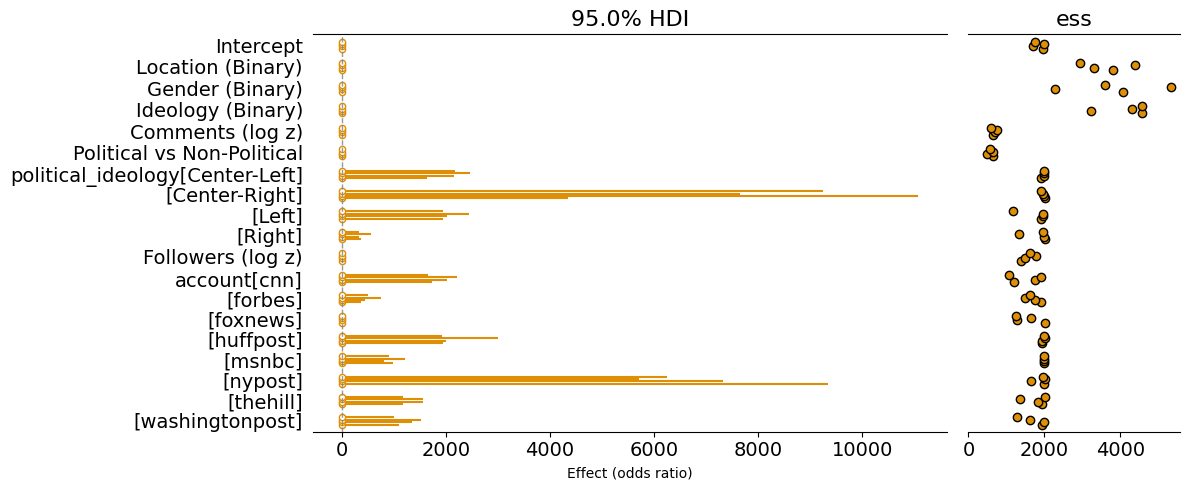

In [38]:
# model = bmb.Model(
#     "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + followers_logz + comments_count_logz + political_ideology + main_topic + account + (1|urlid)",
#     data=reg_news_df,
#     family="beta_binomial",
#     # dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.97,
#     chains=4,
#     cores=1,
#     random_seed=42,
#     prob=0.95
# )
# var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff',
#              'comments_count_logz', 'main_topic', 'political_ideology', 'followers_logz', 'account']
# df = az.summary(results, var_names=var_names)
# df = df.rename(index=edit_labels)
# display(df)

# axes = az.plot_forest(
#     results,
#     combined=False,
#     hdi_prob=0.95,
#     transform=np.exp,
#     figsize=(12, 5),
#     r_hat=False,
#     ess=True,
#     var_names=var_names,
#     colors='C1'
# )

# ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
# new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
# ax.set_yticklabels(new_labels)

# ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
# ax.set_xlabel("Effect (odds ratio)")
# plt.tight_layout()
# plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [kappa, Intercept, location, gender, ideology, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 2 chains for 2_000 tune and 2_000 draw iterations (4_000 + 4_000 draws total) took 84 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.454,0.265,-2.943,-1.948,0.016,0.010,282.0,481.0,1.01
Location[ny_texas],-0.238,0.058,-0.343,-0.128,0.001,0.001,3221.0,2468.0,1.00
Location[ny_ny],-0.017,0.063,-0.136,0.102,0.001,0.001,3321.0,2871.0,1.00
Gender[female_male],0.060,0.058,-0.043,0.174,0.001,0.001,3273.0,2596.0,1.00
Gender[female_female],-0.401,0.074,-0.545,-0.265,0.001,0.001,3742.0,2894.0,1.00
Leaning[dem_rep],-0.037,0.058,-0.153,0.065,0.001,0.001,3929.0,2973.0,1.00
Leaning[dem_dem],-0.881,0.081,-1.034,-0.727,0.001,0.001,4105.0,3036.0,1.00
Post Type [Non-Political][Non-Political],-0.753,0.347,-1.383,-0.091,0.023,0.013,229.0,343.0,1.00


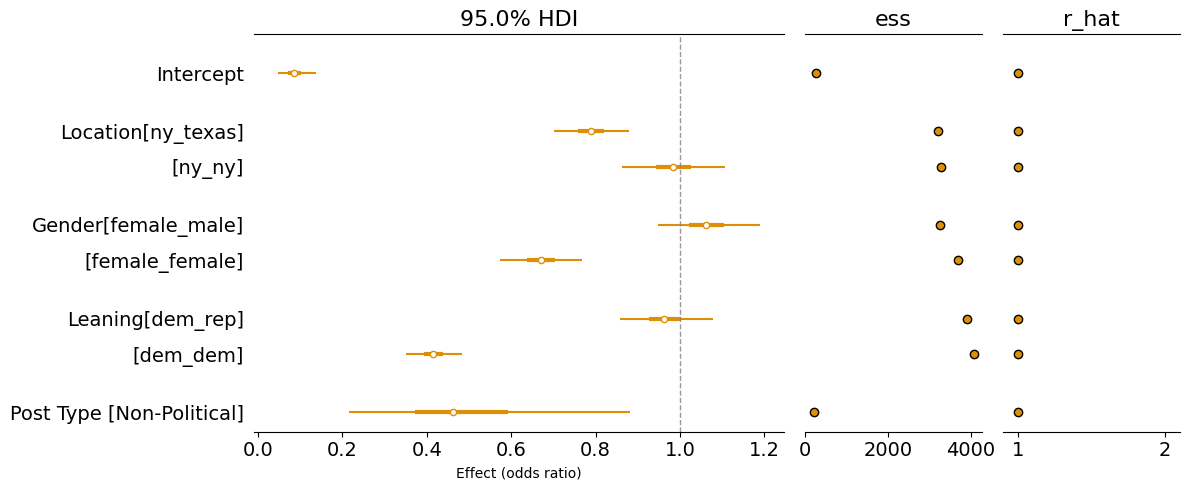

In [44]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + main_topic + (1|urlid)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=2,
    cores=2,
    random_seed=42,
    prob=0.95
)
var_names = ['Intercept', 'location', 'gender', 'ideology',
             'main_topic']
df = az.summary(results, var_names=var_names)
df = df.rename(index=edit_labels)
display(df)

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.95,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=True,
    ess=True,
    var_names=var_names,
    colors='C1'
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
new_labels = [edit_labels(t.get_text()) for t in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Default computed for unspecified variable: gender, ideology, main_topic, urlid
Default computed for unspecified variable: ideology, location, main_topic, urlid
Default computed for unspecified variable: gender, location, main_topic, urlid
Default computed for unspecified variable: gender, ideology, location, urlid


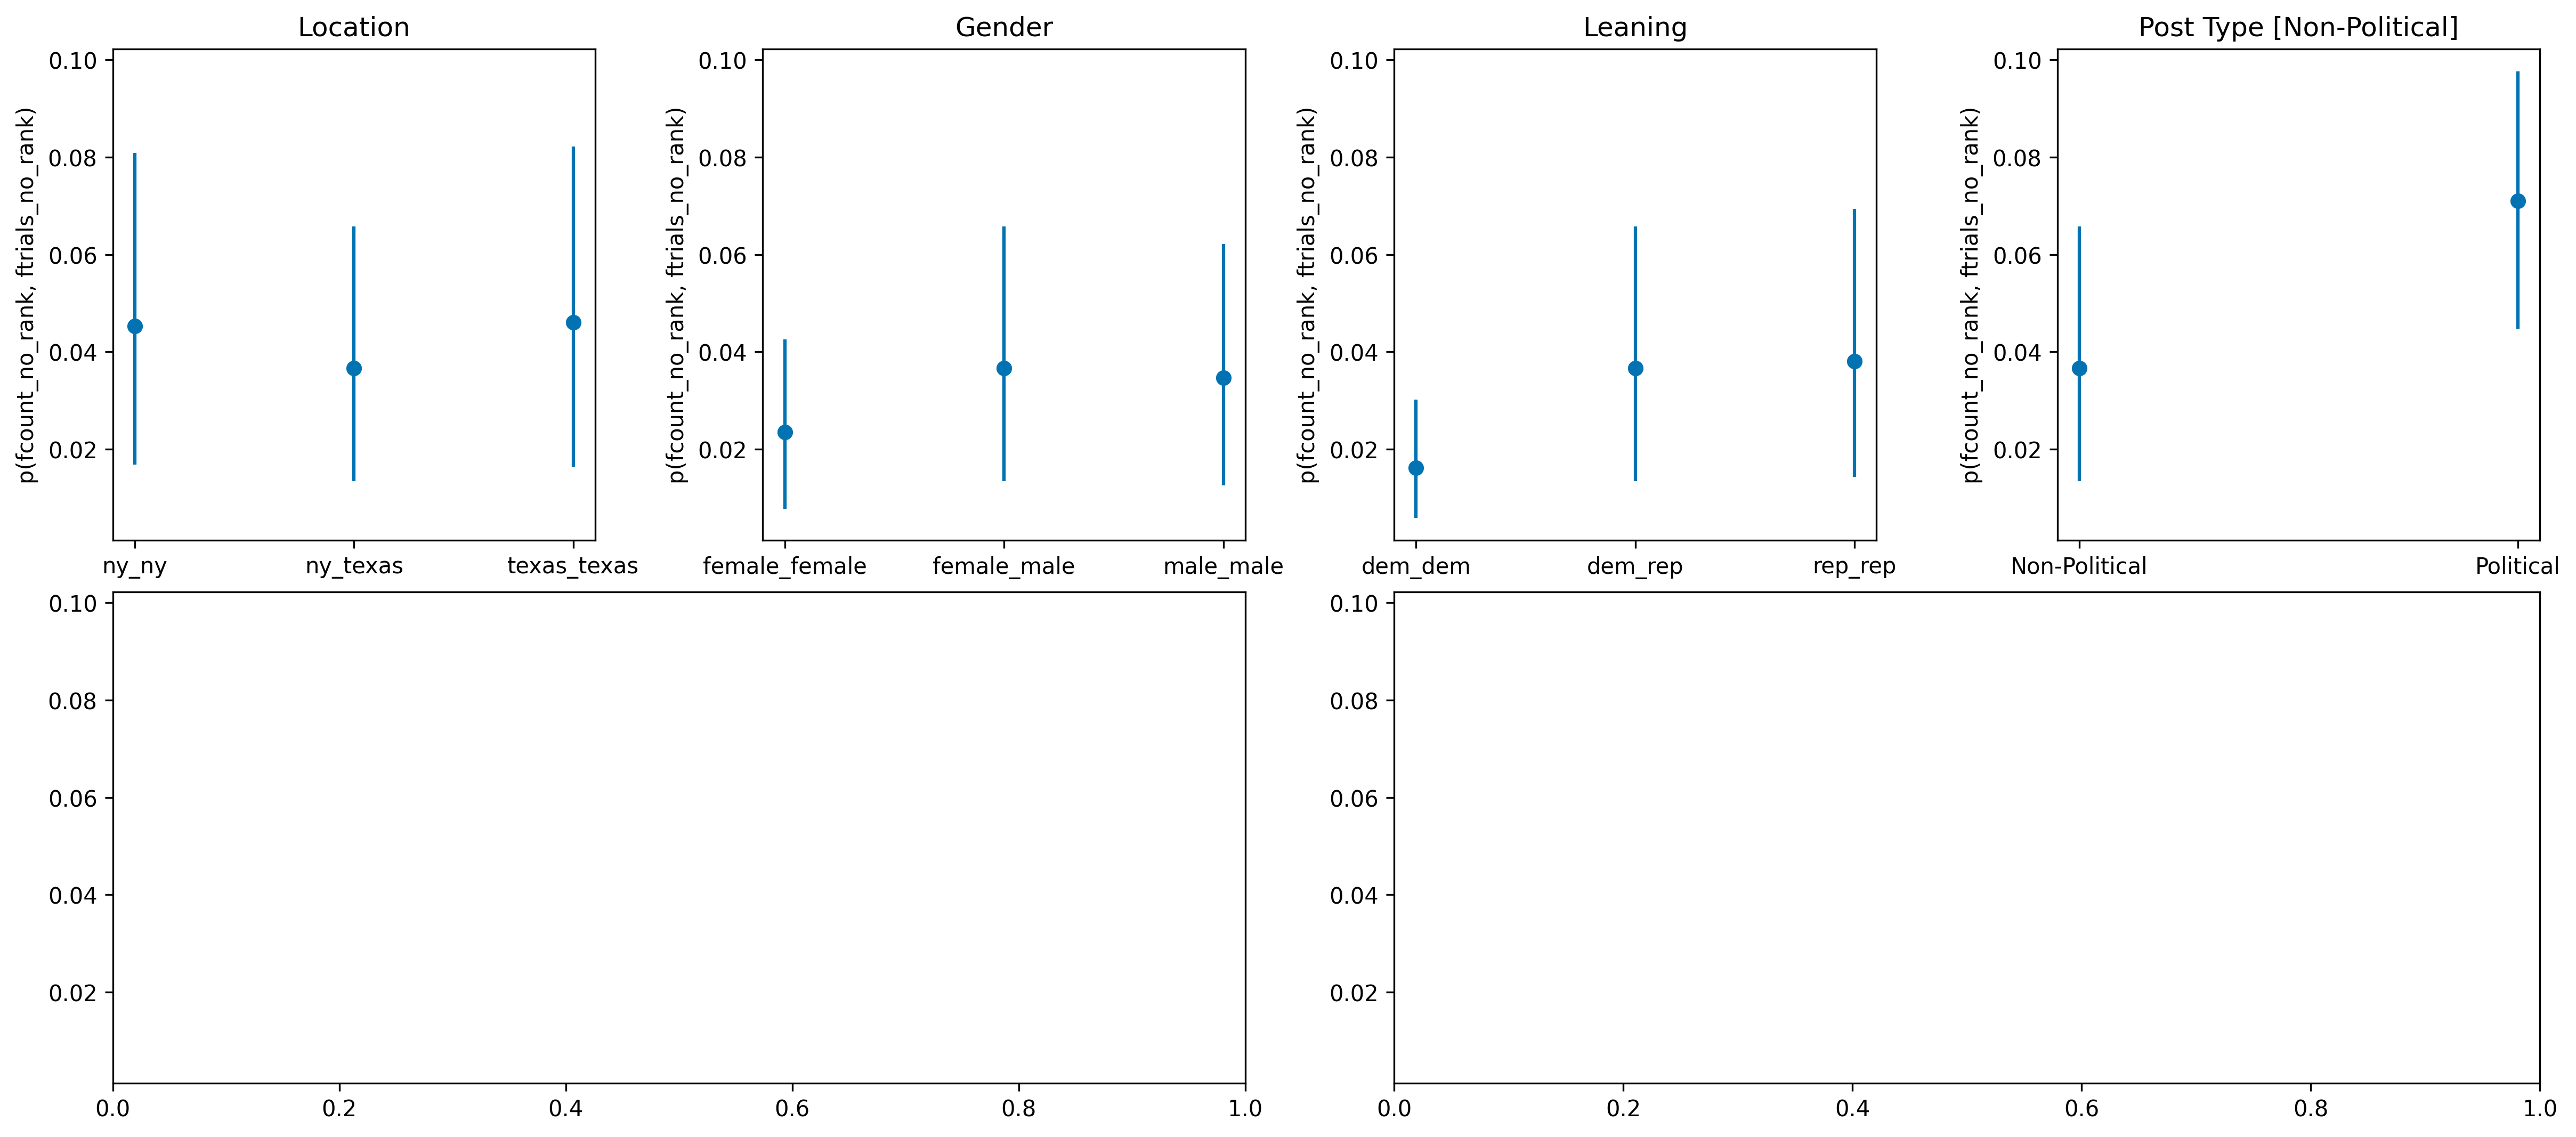

In [45]:
first_row = ["location", "gender"]
second_row = ["ideology", "main_topic"]
conditionals = first_row + second_row

data = model.data 

fig = plt.figure(figsize=(16, 7), dpi=300, constrained_layout=True)
gs = fig.add_gridspec(2, 4)

axes = []
ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

for c in range(1, 4):
    axes.append(fig.add_subplot(gs[0, c], sharey=ax0))

axes.append(fig.add_subplot(gs[1, 0:2], sharey=ax0))
axes.append(fig.add_subplot(gs[1, 2:4], sharey=ax0))

def conditional_spec(var):
    u = pd.Series(data[var]).dropna().unique().tolist()
    if len(u) <= 5:
        try:
            u_sorted = sorted(u, key=lambda x: float(x))
        except Exception:
            u_sorted = sorted(u, key=lambda x: str(x))
        return {var: u_sorted}, u_sorted
    return var, None

for ax, var in zip(axes, conditionals):
    cond, levels = conditional_spec(var)

    fig2, _ = bmb.interpret.plot_predictions(
        model, results,
        conditional=cond,
        prob=0.95,
        use_hdi=True,
        pps=False,
        legend=False,
        ax=ax,
    )
    if fig2 is not fig:
        plt.close(fig2)


    ax.set_title(edit_labels(var))
    ax.set_xlabel('')

    leg = ax.get_legend()
    if leg is not None:
        for t in leg.get_texts():
            t.set_text(edit_labels(t.get_text()))
        leg.set_title(edit_labels(leg.get_title().get_text()))

    if isinstance(cond, dict) and levels is not None:
        try:
            lv = np.array(levels, dtype=float)
            if lv.size == 2:
                ax.set_xlim(lv.min() - 0.2, lv.max() + 0.2)
                ax.set_xticks(sorted(lv))
        except Exception:
            pass

    # BROWN = "#fa7700"
    # for ln in ax.lines:
    #     ln.set_color(BROWN)

    # for coll in ax.collections:  # often includes the interval band
    #     try:
    #         coll.set_facecolor(BROWN)
    #         coll.set_edgecolor(BROWN)
    #         coll.set_alpha(0.2)
    #     except Exception:
    #         pass

# right_edge_axes = [axes[3], axes[5]]
# for ax in right_edge_axes:
#     ax.yaxis.set_ticks_position("both")
#     ax.tick_params(axis="y", right=True, labelright=True)

# for ax in axes:
#     if ax not in right_edge_axes:
#         ax.tick_params(axis="y", right=True, labelright=False)

plt.show()

### political/non-political

In [15]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)

In [16]:
reg_news_df.shape

(4648, 9)

In [17]:
reg_news_df

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank
0,ny_texas,male_male,dem_dem,DRWBiQXDG0H,breitbart,0.0,20.0,3.0,10.0
1,ny_texas,male_male,dem_dem,DRWXFT9DRtK,breitbart,0.0,20.0,4.0,10.0
2,ny_texas,male_male,dem_dem,DRWhnmjDo-i,breitbart,0.0,20.0,2.0,10.0
3,ny_texas,male_male,dem_dem,DRXIibxjFKK,breitbart,2.0,20.0,5.0,9.0
4,ny_texas,male_male,dem_dem,DRXUNHfDYvW,breitbart,0.0,20.0,0.0,10.0
...,...,...,...,...,...,...,...,...,...
4643,ny_texas,female_female,rep_rep,DRX-31ODa_2,washingtonpost,0.0,20.0,4.0,10.0
4644,ny_texas,female_female,rep_rep,DRXO1Q9Co1Y,washingtonpost,0.0,20.0,0.0,10.0
4645,ny_texas,female_female,rep_rep,DRXf-IGj2TH,washingtonpost,0.0,20.0,2.0,10.0
4646,ny_texas,female_female,rep_rep,DRXw_eDjr9l,washingtonpost,0.0,20.0,0.0,10.0


In [18]:
reg_news_df.drop_duplicates(inplace=True)
reg_news_df.dropna(inplace=True)

reg_news_df.shape

(2114, 9)

In [34]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

news_df = pd.merge(news_df, accounts_data, on='account', how='inner')
news_df.shape

(980, 23)

In [35]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(news_df['urlid'].unique().tolist())]
posts_data.shape[0] == news_df['urlid'].nunique()

news_df = pd.merge(news_df, posts_data, on='urlid', how='inner')
news_df.drop(columns=['Url'], inplace=True)
news_df.shape

(980, 27)

In [40]:
news_df[['account', 'main_topic', 'urlid']].drop_duplicates()[['account', 'main_topic']].value_counts()

account         main_topic   
nypost          Non-Political    10
forbes          Non-Political     9
huffpost        Political         9
msnbc           Political         8
thehill         Political         8
foxnews         Non-Political     7
breitbart       Political         6
washingtonpost  Non-Political     6
cnn             Non-Political     5
                Political         5
breitbart       Non-Political     3
foxnews         Political         3
washingtonpost  Political         2
msnbc           Non-Political     1
thehill         Non-Political     1
Name: count, dtype: int64

In [ ]:
# ct = pd.crosstab(news_df["account"], news_df["main_topic"])
# ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# plt.figure()
# ct.plot(kind="bar", stacked=False)
# plt.xlabel("account")
# plt.ylabel("count")
# plt.title("main_topic by account (grouped)")
# plt.xticks(rotation=45, ha="right")
# plt.tight_layout()
# plt.show()


In [29]:
reg_news_df[['account', 'main_topic', 'urlid', 'fcount_no_rank', 'ftrials_no_rank']].drop_duplicates()

,account,main_topic,urlid,fcount_no_rank,ftrials_no_rank
0,breitbart,Political,DRWBiQXDG0H,0.0,20.0
1,breitbart,Political,DRWXFT9DRtK,0.0,20.0
2,breitbart,Political,DRWhnmjDo-i,0.0,20.0
3,breitbart,Non-Political,DRXIibxjFKK,2.0,20.0
4,breitbart,Non-Political,DRXUNHfDYvW,0.0,20.0
...,...,...,...,...,...
1728,washingtonpost,Non-Political,DRXf-IGj2TH,0.0,20.0
1749,cnn,Political,DRYdbIKj3Zo,4.0,20.0
1858,huffpost,Political,DRVXN3TAbH-,6.0,20.0
2069,huffpost,Political,DRQry8hjLUz,0.0,16.0


,account,main_topic,n,avg_fcount,avg_ftrials,avg_rate
0,breitbart,Non-Political,77,1.818182,20.000000,0.090909
1,breitbart,Political,151,1.827815,20.000000,0.091391
2,cnn,Non-Political,130,2.369231,20.000000,0.118462
3,cnn,Political,129,2.124031,20.000000,0.106202
4,forbes,Non-Political,214,0.738318,20.000000,0.036916
5,foxnews,Non-Political,184,1.141304,20.000000,0.057065
6,foxnews,Political,76,1.921053,20.000000,0.096053
7,huffpost,Political,228,1.934211,19.539474,0.098898
8,msnbc,Non-Political,20,0.900000,20.000000,0.045000
9,msnbc,Political,174,1.356322,20.000000,0.067816


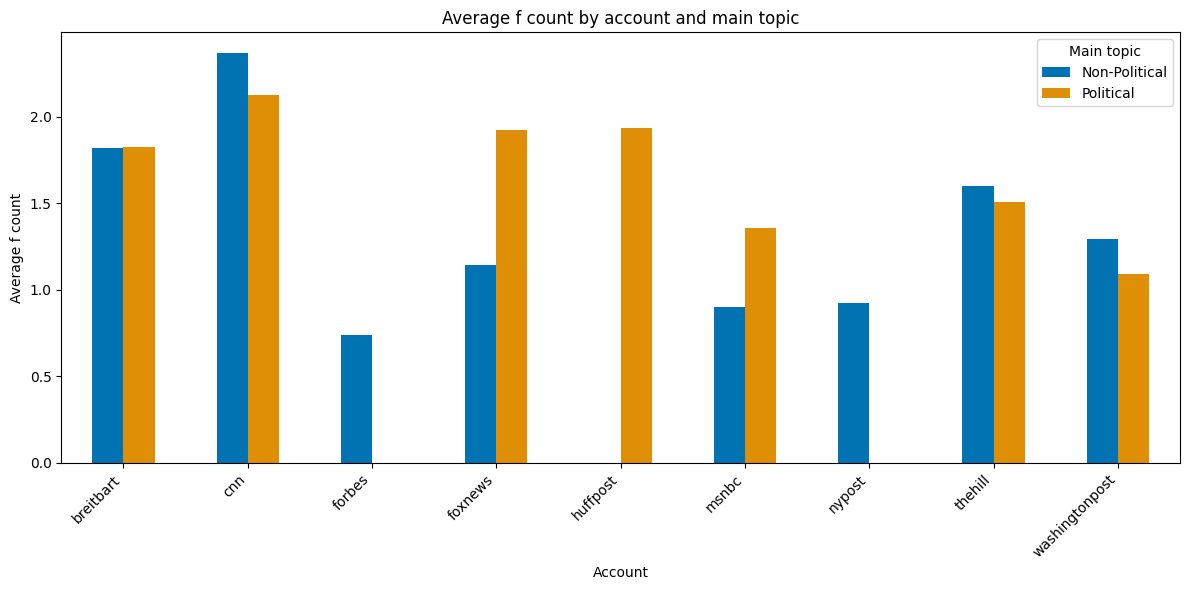

In [41]:
df2 = reg_news_df.copy()
df2["fcount_no_rank"] = pd.to_numeric(df2["fcount_no_rank"], errors="coerce")
df2["ftrials_no_rank"] = pd.to_numeric(df2["ftrials_no_rank"], errors="coerce")

df2 = df2[
    df2["fcount_no_rank"].ne(-1) &
    df2["ftrials_no_rank"].ne(-1)
].copy()

df2["rate"] = df2["fcount_no_rank"] / df2["ftrials_no_rank"]

df2 = df2[df2["main_topic"].isin(["Political", "Non-Political"])].copy()

avg_by_combo = (
    df2.groupby(["account", "main_topic"], as_index=False)
       .agg(
           n=("urlid", "count"),
           avg_fcount=("fcount_no_rank", "mean"),
           avg_ftrials=("ftrials_no_rank", "mean"),
           avg_rate=("rate", "mean"),
       )
       .sort_values(["account", "main_topic"])
)

# value_col = "fcount_no_rank" 
# for acct, g in df2.groupby("account"):
#     gp = g[g["main_topic"] == "Political"][value_col].dropna().to_numpy()
#     gnp = g[g["main_topic"] == "Non-Political"][value_col].dropna().to_numpy()

#     if len(gp) == 0 and len(gnp) == 0:
#         continue

#     allx = np.concatenate([gp, gnp]) if (len(gp) and len(gnp)) else (gp if len(gp) else gnp)

#     xmin, xmax = np.nanmin(allx), np.nanmax(allx)
#     if np.isfinite(xmin) and np.isfinite(xmax) and xmin != xmax:
#         bins = np.linspace(xmin, xmax, 21)
#     else:
#         bins = 10

#     fig, ax = plt.subplots(figsize=(7, 4))

#     if len(gp):
#         ax.hist(gp, bins=bins, density=True, histtype="bar", linewidth=2, label=f"Political (n={len(gp)})", stacked=True)
#     if len(gnp):
#         ax.hist(gnp, bins=bins, density=True, histtype="bar", linewidth=2, label=f"Non-Political (n={len(gnp)})", stacked=True)

#     ax.set_title(f"{acct} — {value_col} distribution")
#     ax.set_xlabel(value_col)
#     ax.set_ylabel("Density")
#     ax.legend()
#     fig.tight_layout()
#     plt.show()

display(avg_by_combo)

pivot = avg_by_combo.pivot(index="account", columns="main_topic", values="avg_fcount").sort_index()

ax = pivot.plot(kind="bar", figsize=(12, 6))
ax.set_title("Average f count by account and main topic")
ax.set_xlabel("Account")
ax.set_ylabel("Average f count")
ax.legend(title="Main topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()